In [18]:
!pip install langchain-huggingface


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import os 
from typing import List, Any, Dict, Union, TypedDict
from langchain_community.vectorstores import FAISS
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings

In [56]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
# os.environ['OPENAI_API_KEY'] = 'ddc-a4f-979e772e101449daa8ebf58e4e3be7ad'
os.environ['OPENAI_API_BASE'] = 'https://api.a4f.co/v1'

In [58]:
# # Initialize the models using custom API provider
# llm = ChatOpenAI(
#     model="provider-2/gemini-2.5-flash",
#     temperature=0,
#     openai_api_key=os.environ['OPENAI_API_KEY'],
#     openai_api_base=os.environ['OPENAI_API_BASE']
# )

# # Use custom embedding model from the same API provider
# embedding_model = OpenAIEmbeddings(
#     model="provider-5/text-embedding-ada-002",
#     openai_api_key=os.environ['OPENAI_API_KEY'],
#     openai_api_base=os.environ['OPENAI_API_BASE']
# )

# llm, embedding_model

In [92]:
# Initialize the models using A4F API provider
llm = ChatOpenAI(
    model="provider-3/google/gemini-2.0-flash",  # Switch to provider-3 with GPT-4o
    temperature=0,
    api_key=os.environ['OPENAI_API_KEY'],
    base_url="https://api.a4f.co/v1"
)

# Use HuggingFace embeddings (free, no API key needed)
embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
llm

ChatOpenAI(profile={}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000018035DB56D0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000180357CBCE0>, root_client=<openai.OpenAI object at 0x00000180351C62A0>, root_async_client=<openai.AsyncOpenAI object at 0x0000018035DB58E0>, model_name='provider-3/google/gemini-2.0-flash', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://api.a4f.co/v1')

# State Definition

In [93]:
class AgentState(TypedDict):
    question: str
    documents: List[Document]
    answer: str
    needs_retrieval: bool

In [94]:
# Sample documents and vectorstore 
sample_texts = [
    "LangGraph is a powerful framework for building applications with language models.",
    "It allows you to create state graphs that define the flow of your application.",
    "With LangGraph, you can easily integrate various components and manage complex interactions."
]
documents = [Document(page_content=text) for text in sample_texts]
vectorstore = FAISS.from_documents(documents, embedding_model)
retriever = vectorstore.as_retriever(k=3)

In [95]:
def decide_retrieval(state: AgentState) -> AgentState:
    """Decides whether document retrieval is needed based on the question."""
    question = state['question'].lower()
    if any(keyword in question for keyword in ['who', 'what', 'when', 'where', 'why', 'how', 'explain', 'define']):
        state['needs_retrieval'] = True
    else:
        state['needs_retrieval'] = False
    return state

In [96]:
def retrieve_documents(state: AgentState) -> AgentState:
    """Retrieves relevant documents if needed."""
    question = state['question']
    docs = retriever.invoke(question)
    return {**state, 'documents': docs}

In [97]:
def generate_answer(state: AgentState) -> AgentState:
    """Generates an answer based on the question and retrieved documents."""
    question = state['question']
    docs = state.get('documents', [])
    if docs:
        context = "\n".join([doc.page_content for doc in docs])
        prompt = f"Using the following context, answer the question:\n\nContext:\n{context}\n\nQuestion: {question}"
    else:
        prompt = f"Answer the question without additional context:\n\nQuestion: {question}"
    response = llm.invoke(prompt)
    return {**state, 'answer': response}

In [98]:
def should_retrieve(state: AgentState) -> str:
    """Determines if document retrieval is needed."""
    if state["needs_retrieval"]:
        return "retrieve"
    else:
        return "generate"

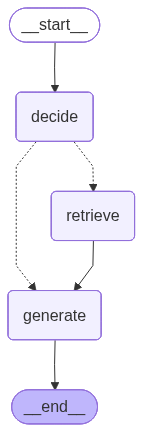

In [99]:
# Create the state graph
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("decide", decide_retrieval)
workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("generate", generate_answer)

# Set entry point
workflow.set_entry_point("decide")

# Add conditional edges
workflow.add_conditional_edges("decide", should_retrieve, {
    "retrieve": "retrieve",
    "generate": "generate"
})

# Add edges
workflow.add_edge("retrieve", "generate")
workflow.add_edge("generate", END)

# Compile
app = workflow.compile()
app

In [100]:
def ask_question(question: str):
    """Helper function to ask a question and get an answer."""
    initial_state = {
        "question": question,
        "documents": [],
        "answer": "",
        "needs_retrieval": False
    }
    result = app.invoke(initial_state)
    return result

In [101]:
# Test API connection
import requests

try:
    response = requests.get("https://api.a4f.co/v1/models", 
                           headers={"Authorization": f"Bearer {os.environ['OPENAI_API_KEY']}"})
    print(f"Status: {response.status_code}")
    print(f"Response: {response.text[:500]}")
except Exception as e:
    print(f"Connection failed: {e}")

Status: 200
Response: {"data":[{"object":"model","id":"provider-3/deepseek-r1-0528","base_model":"deepseek-r1-0528","features":["vision","reasoning"],"context_window":81920,"type":"chat/completion"},{"object":"model","id":"provider-3/deepseek-v3","base_model":"deepseek-v3","features":["vision","function_calling"],"context_window":81920,"type":"chat/completion"},{"object":"model","id":"provider-3/llama-3-70b","base_model":"llama-3-70b","features":["function_calling"],"context_window":8192,"type":"chat/completion"},{"o


In [102]:
# Test with a question that should trigger retrieval
question1 = "What is LangGraph?"
result1 = ask_question(question1)
print(f"Question: {question1}")
print(f"Needs Retrieval: {result1['needs_retrieval']}")
print(f"Documents Retrieved: {len(result1['documents'])}")
print(f"Answer: {result1['answer'].content}")

NotFoundError: Error code: 404 - {'error': {'message': "The requested model 'provider-3/google/gemini-2.0-flash' does not exist or you do not have access to it.", 'type': 'not_found_error', 'code': 'model_not_found', 'param': 'model'}}